# Monte Carlo VaR

This notebook estimates portfolio Value at Risk using Monte Carlo simulation.

Unlike Historical VaR, which relies directly on observed historical returns, and Parametric VaR, which assumes a specific return distribution, Monte Carlo VaR generates a large number of hypothetical portfolio return scenarios based on estimated portfolio characteristics.

The simulation preserves the historical covariance structure between the assets.

The analysis will:

1. Construct the portfolio using the same assets and weights used in the previous notebooks.
2. Estimate the portfolio mean vector and covariance matrix.
3. Generate correlated asset-return scenarios using Monte Carlo simulation.
4. Calculate simulated portfolio returns.
5. Estimate 95% and 99% Monte Carlo VaR.
6. Estimate Monte Carlo Expected Shortfall.
7. Compare Monte Carlo results with Historical and Parametric VaR.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices


## 1. Construct the portfolio

In [31]:
tickers = ["SPY", "QQQ", "IWM", "TLT", "GLD"]
weights = pd.Series({
    "SPY": 0.30,
    "QQQ": 0.20,
    "IWM": 0.15,
    "TLT": 0.20,
    "GLD": 0.15
})

weights = weights.reindex(returns.columns)

prices = download_prices(
    tickers=tickers,
    start="2015-01-01",
    end="2026-01-01"
)

returns = prices.pct_change().dropna()



[*********************100%***********************]  5 of 5 completed


## 2. Estimate the portfolio mean and covariance

Monte Carlo simulation requires estimates of the statistical characteristics of the asset returns. The historical mean return vector and covariance matrix are used as inputs to the simulation.  
The covariance matrix captures the relationships between assets, allowing the simulated return scenarios to preserve the historical cross-asset dependence structure.

In [32]:
mean_returns = returns.mean()
covariance_matrix = returns.cov()
covariance_matrix

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,0.000086,0.000006,0.000007,0.000005,0.000025
IWM,0.000006,0.000201,0.000151,0.000138,-0.000022
QQQ,0.000007,0.000151,0.000192,0.000145,-0.000017
SPY,0.000005,0.000138,0.000145,0.000126,-0.000020
TLT,0.000025,-0.000022,-0.000017,-0.000020,0.000090


In [33]:
returns.head(5)

Ticker,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2015-01-05,0.015077,-0.013369,-0.014669,-0.018059,0.015708
2015-01-06,0.011399,-0.017300,-0.013408,-0.009419,0.018017
2015-01-07,-0.005891,0.012315,0.012891,0.012462,-0.001975
2015-01-08,-0.004209,0.016962,0.019139,0.017745,-0.013243
2015-01-09,0.011385,-0.009603,-0.006582,-0.008014,0.010953


## 3. Generate correlated asset-return scenarios using Monte Carlo simulation

Independent standard normal shocks are first generated for each asset. The Cholesky decomposition of the historical covariance matrix is then used to transform these independent shocks into correlated shocks.
The simulated asset returns are therefore generated as:

$$
R_{\text{sim}} = \mu + LZ
$$

where $\mu$ is the vector of historical mean returns, $L$ is the Cholesky factor of the covariance matrix, and $Z$ is a vector of independent standard normal shocks.
This produces 100,000 hypothetical joint return scenarios for the portfolio.

In [34]:
n_simulations = 100_000
random_seed = 42

np.random.seed(random_seed)

In [35]:
cholesky_matrix = np.linalg.cholesky(covariance_matrix)
cholesky_matrix

array([[ 0.00928985,  0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.00066085,  0.0141794 ,  0.        ,  0.        ,  0.        ],
       [ 0.00072324,  0.01062937,  0.00884523,  0.        ,  0.        ],
       [ 0.0004956 ,  0.00970757,  0.00467836,  0.00304216,  0.        ],
       [ 0.00266185, -0.0016731 , -0.00015422, -0.0013147 ,  0.00883867]])

In [36]:
random_shocks = np.random.normal(
    size=(n_simulations, len(tickers))
)

random_shocks[:5]

array([[ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337],
       [-0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004],
       [-0.46341769, -0.46572975,  0.24196227, -1.91328024, -1.72491783],
       [-0.56228753, -1.01283112,  0.31424733, -0.90802408, -1.4123037 ],
       [ 1.46564877, -0.2257763 ,  0.0675282 , -1.42474819, -0.54438272]])

In [37]:
correlated_shocks = random_shocks @ cholesky_matrix.T
correlated_shocks[:5]

array([[ 0.0046144 , -0.00163225,  0.00461853,  0.00656738, -0.00261831],
       [-0.0021751 ,  0.02223756,  0.02340484,  0.01737639,  0.00202897],
       [-0.00430508, -0.00691002, -0.00314536, -0.00943929, -0.01322225],
       [-0.00522357, -0.01473293, -0.00839283, -0.01140299, -0.01113973],
       [ 0.01361566, -0.0022328 , -0.00074255, -0.00548376,  0.00133016]])

In [38]:
simulated_returns = (
    correlated_shocks + mean_returns.values
)

simulated_returns[:5]


array([[ 5.10805430e-03, -1.21575218e-03,  5.39070127e-03,
         7.13161299e-03, -2.60369286e-03],
       [-1.68144636e-03,  2.26540603e-02,  2.41770070e-02,
         1.79406249e-02,  2.04357953e-03],
       [-3.81143109e-03, -6.49351859e-03, -2.37319557e-03,
        -8.87506128e-03, -1.32076318e-02],
       [-4.72991751e-03, -1.43164258e-02, -7.62066726e-03,
        -1.08387568e-02, -1.11251187e-02],
       [ 1.41093162e-02, -1.81629978e-03,  2.96210952e-05,
        -4.91952939e-03,  1.34477471e-03]])

## 4 Calculate simulated portfolio returns

Each simulated asset-return scenario is converted into a portfolio return using the predefined portfolio weights:

$$
R_p = \sum_i w_i R_i
$$

The resulting distribution represents the simulated one-day portfolio return distribution.

In [39]:
simulated_portfolio_returns = simulated_returns @ weights.values

In [40]:
pd.Series(simulated_portfolio_returns).describe()

count    100000.000000
mean          0.000474
std           0.008068
min          -0.038355
25%          -0.004994
50%           0.000466
75%           0.005931
max           0.037050
dtype: float64

### Simulated vs. Empirical Portfolio Returns

The simulated return distribution is compared with the empirical portfolio return distribution observed over the historical sample. This provides a visual check of how closely the Monte Carlo model reproduces the characteristics of the observed portfolio returns.


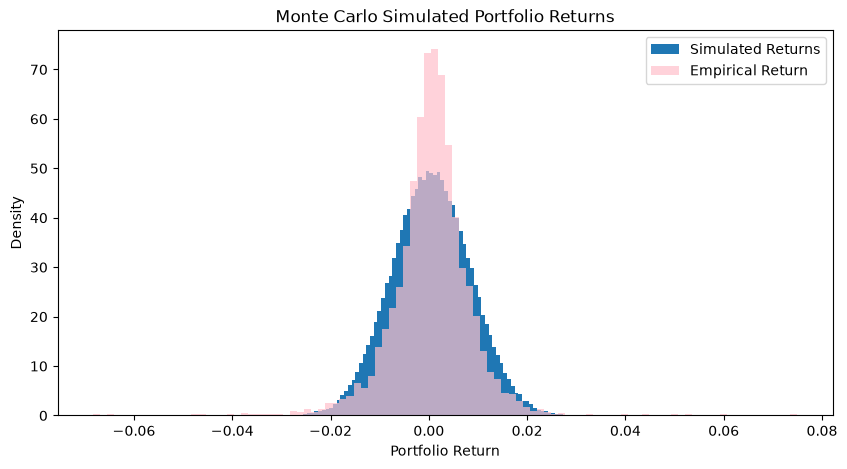

In [41]:
plt.figure(figsize=(10,5))

plt.hist(
    simulated_portfolio_returns,
    bins=100,
    density=True,
    alpha = 1,
    label = "Simulated Returns"
)

plt.hist(
    returns.values @ weights.values,
    bins=100,
    color = "pink",
    density=True,
    alpha = 0.7,
    label = "Empirical Return"
)

plt.title("Monte Carlo Simulated Portfolio Returns")
plt.xlabel("Portfolio Return")
plt.ylabel("Density")
plt.legend()

plt.show()

## 5. Estimate Monte Carlo VaR

Monte Carlo VaR is estimated from the lower tail of the simulated portfolio return distribution. The 5th percentile is used for 95% VaR and the 1st percentile for 99% VaR.
VaR is reported as a positive loss magnitude, so the negative return quantile is multiplied by -1.

In [42]:
confidence_levels = [0.95, 0.99]

monte_carlo_var = {}

for level in confidence_levels:
    quantile = 1-level
    var_return = pd.Series(simulated_portfolio_returns).quantile(quantile)
    monte_carlo_var[level] = -var_return

monte_carlo_var


{0.95: np.float64(0.012813937444304485),
 0.99: np.float64(0.018040297961162428)}

The 99% VaR is higher than the 95% VaR because it represents a more extreme point in the simulated loss distribution.

## 6. Estimate Monte Carlo Expected Shortfall

Expected Shortfall measures the average loss conditional on the portfolio return falling beyond the VaR threshold. Unlike VaR, which identifies a percentile of the loss distribution, ES describes the severity of losses in the tail beyond that percentile.
The calculation therefore averages all simulated returns below the corresponding VaR return threshold.

In [44]:
monte_carlo_es = {}

for level in confidence_levels:
    var_return = -monte_carlo_var[level]
    tail_returns = simulated_portfolio_returns[simulated_portfolio_returns<var_return]
    es = -tail_returns.mean()
    monte_carlo_es[level] = es
    
monte_carlo_es

{0.95: np.float64(0.016071782866239153),
 0.99: np.float64(0.020829346770977714)}

In [49]:
monte_carlo_risk = pd.DataFrame({
    "Confidence Levels": confidence_levels,
    "Monte Carlo VaR" : [
        monte_carlo_var[0.95],
        monte_carlo_var[0.99]
    ],
    "Monte Carlo ES" : [
        monte_carlo_es[0.95],
        monte_carlo_es[0.99]
    ]}
)


monte_carlo_risk

,Confidence Levels,Monte Carlo VaR,Monte Carlo ES
0,0.95,0.012814,0.016072
1,0.99,0.018040,0.020829


## 7. Final comparison of all three VaR methods

The three VaR approaches are compared to assess how the choice of methodology affects the estimated portfolio risk.
Historical VaR uses the empirical return distribution, Parametric VaR assumes normally distributed portfolio returns, and Monte Carlo VaR generates hypothetical scenarios using the estimated mean vector and covariance matrix.

In [ ]:
from project_01_market_risk_engine.src.var import historical_var, parametric_var

historical_95_var = historical_var(
    returns @ weights,
    confidence_level=0.95
)

historical_95_var

np.float64(0.011847721174654765)

In [52]:
from project_01_market_risk_engine.src.var import historical_var, parametric_var

var_results = {}

for level in confidence_levels:
    var_results[level] = {
        "Historical VaR": historical_var(returns @ weights, confidence_level=level),
        "Parametric VaR": parametric_var(returns @ weights, confidence_level=level)
    }
    
var_results

{0.95: {'Historical VaR': np.float64(0.011847721174654765),
  'Parametric VaR': np.float64(0.01284357668185147)},
 0.99: {'Historical VaR': np.float64(0.0218013048043941),
  'Parametric VaR': np.float64(0.01835680683548267)}}

In [54]:
var_table = pd.DataFrame.from_dict(var_results, orient='index')

# 2. Add Monte Carlo VaR column from the flat dictionary
var_table['Monte Carlo VaR'] = pd.Series(monte_carlo_var)

# 3. Clean up Index and Column formatting
var_table.index.name = 'Confidence Level'
var_table.index = [f"{int(cl * 100)}%" for cl in var_table.index]

var_table

,Historical VaR,Parametric VaR,Monte Carlo VaR
95%,0.011848,0.012844,0.012814
99%,0.021801,0.018357,0.018040


### Key Observations

- Historical, Parametric, and Monte Carlo VaR produce relatively similar estimates at the 95% confidence level.
- Parametric and Monte Carlo VaR are particularly close because both approaches assume normally distributed returns.
- At the 99% confidence level, Historical VaR is materially higher than both normal-based approaches.
- This difference suggests that the normal distribution may underestimate the empirical extreme left tail of the portfolio return distribution.
- Monte Carlo simulation provides a flexible framework for incorporating alternative distributional assumptions and more complex risk-factor dynamics. In this implementation, however, the simulated returns are based on normally distributed shocks and the historical covariance structure.